C:\Users\VICTUS\AppData\Local\Temp\ipykernel_29796\2994615870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='cluster', y='ai_understand', palette='magma')
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_29796\2994615870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='cluster', y='visual', palette='magma')


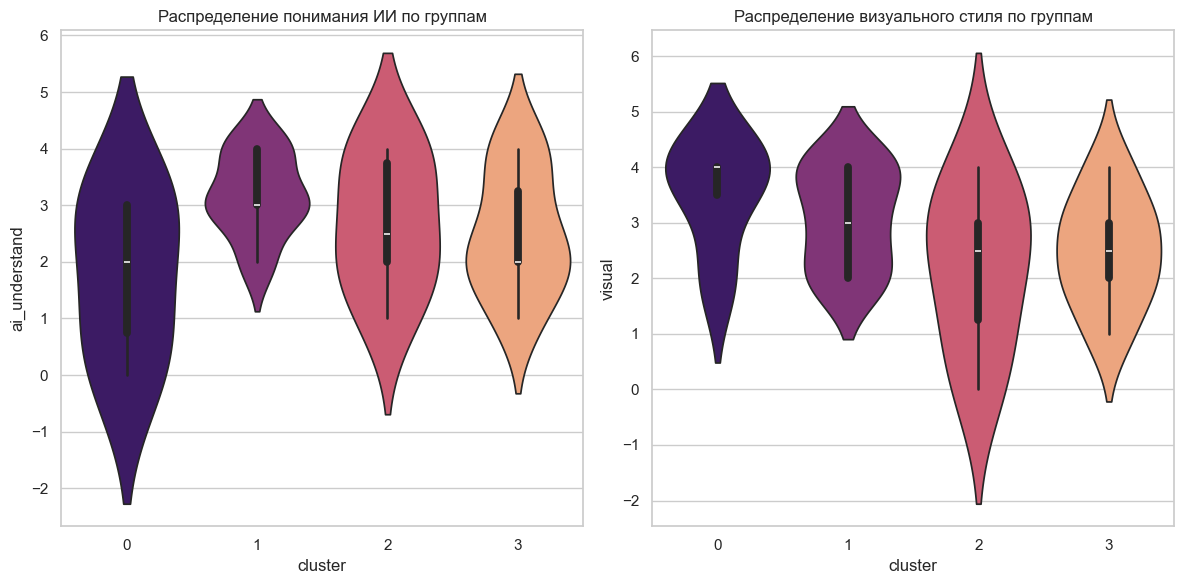

In [9]:
# Посмотрим, как группы различаются по уровню понимания ИИ (ai_understand)
# и по визуальному восприятию (visual)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.violinplot(data=df, x='cluster', y='ai_understand', palette='magma')
plt.title('Распределение понимания ИИ по группам')

plt.subplot(1, 2, 2)
sns.violinplot(data=df, x='cluster', y='visual', palette='magma')
plt.title('Распределение визуального стиля по группам')

plt.tight_layout()
plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_29796\2608109875.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='cluster', y='ai_use', palette='viridis')


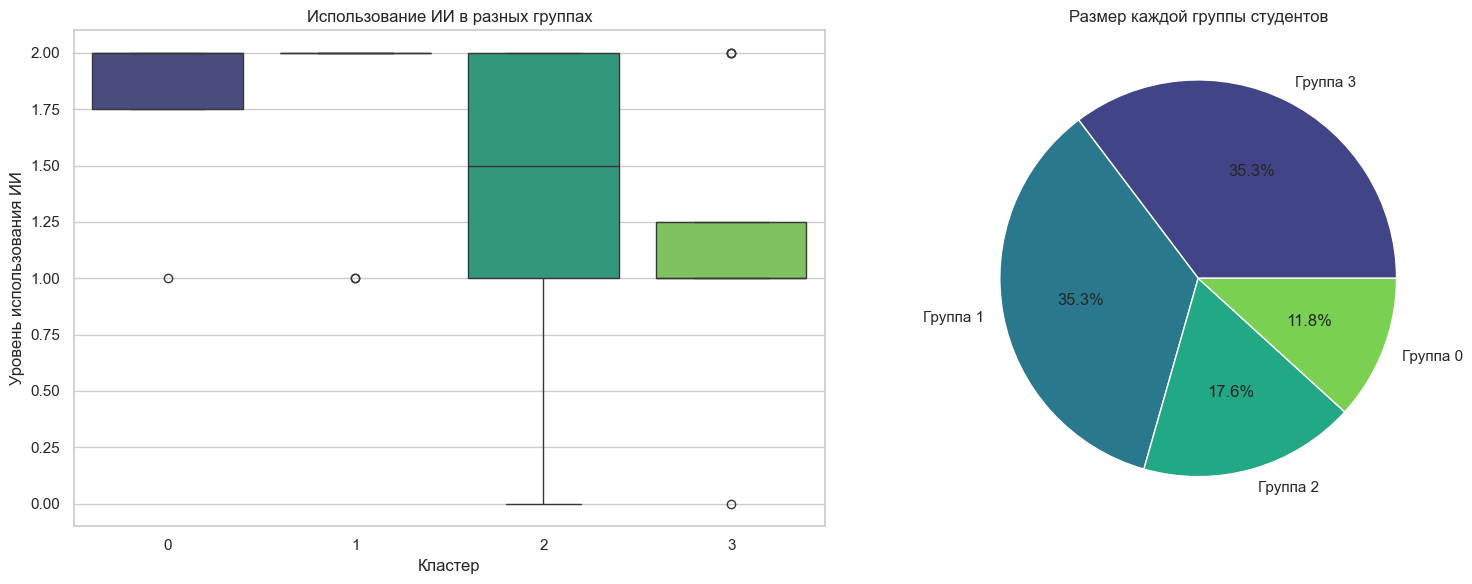

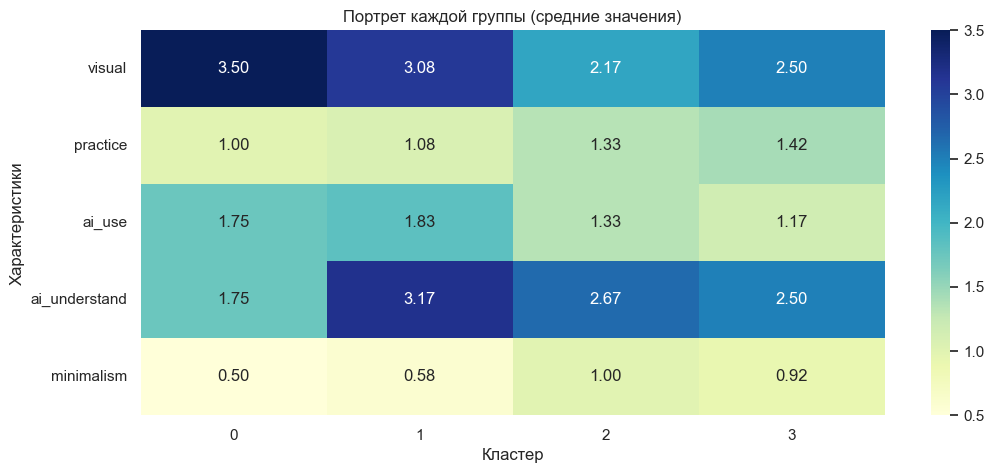

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Устанавливаем стиль
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Распределение использования ИИ по кластерам
sns.boxplot(ax=axes[0], data=df, x='cluster', y='ai_use', palette='viridis')
axes[0].set_title('Использование ИИ в разных группах')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('Уровень использования ИИ')

# 2. Соотношение размеров групп (Круговая диаграмма)
cluster_counts = df['cluster'].value_counts()
axes[1].pie(cluster_counts, labels=[f'Группа {i}' for i in cluster_counts.index], 
        autopct='%1.1f%%', colors=sns.color_palette('viridis', len(cluster_counts)))
axes[1].set_title('Размер каждой группы студентов')

plt.tight_layout()
plt.show()

# 3. Тепловая карта средних значений (в отдельном окне для четкости)
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile[['visual', 'practice', 'ai_use', 'ai_understand', 'minimalism']].T, 
            annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Портрет каждой группы (средние значения)')
plt.xlabel('Кластер')
plt.ylabel('Характеристики')
plt.show()

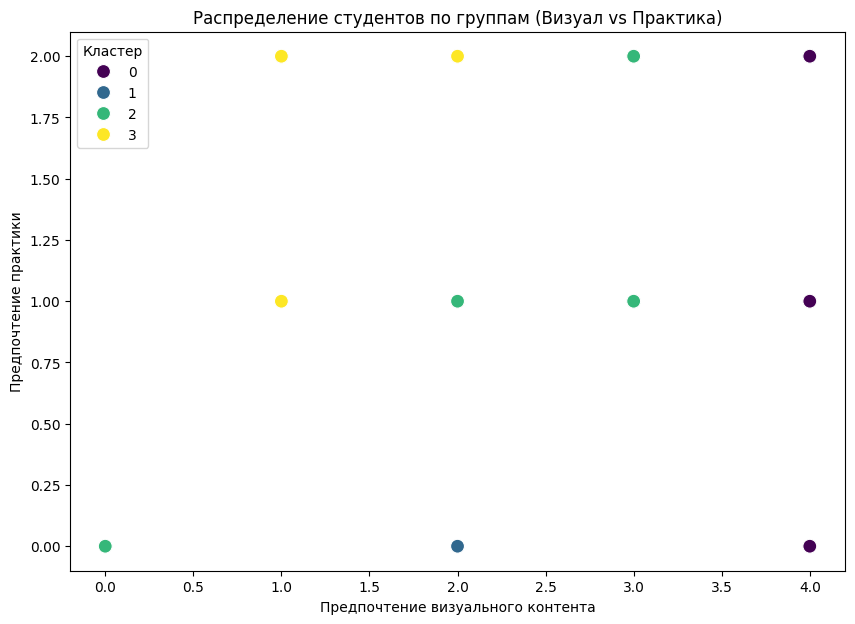

✅ Файл clustered_students.csv сохранен в папку data!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построим график распределения по двум важным признакам
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='visual', y='practice', hue='cluster', palette='viridis', s=100)

plt.title('Распределение студентов по группам (Визуал vs Практика)')
plt.xlabel('Предпочтение визуального контента')
plt.ylabel('Предпочтение практики')
plt.legend(title='Кластер')
plt.show()

# Сохраняем итоговый файл с метками групп
df.to_csv("../data/clustered_students.csv", index=False)
print("✅ Файл clustered_students.csv сохранен в папку data!")

In [5]:
# 1. Запускаем K-Means с k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. Считаем средние значения для профиля групп
cluster_profile = df.groupby('cluster').mean(numeric_only=True)

# 3. Выводим результат
print("✅ Кластеризация завершена!")
print("Количество студентов в каждой группе:")
print(df['cluster'].value_counts().sort_index())

# Покажем средние значения по группам
display(cluster_profile)

✅ Кластеризация завершена!
Количество студентов в каждой группе:
cluster
0     4
1    12
2     6
3    12
Name: count, dtype: int64


,visual,practice,ai_use,ai_help,ai_understand,minimalism,practice_best,notes,study_type,study_time,...,ai_purpose_fun,ai_purpose_study,perception_video_images,perception_memorization,perception_practice,perception_text,learning_style_visual,learning_style_memorization,learning_style_minimalism,learning_style_practical
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.500000,1.000000,1.750000,1.500000,1.750000,0.500000,1.750000,0.50,0.750000,1.750000,...,0.250000,0.750000,1.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.75
1,3.083333,1.083333,1.833333,2.000000,3.166667,0.583333,1.166667,2.25,0.583333,1.500000,...,0.500000,1.000000,0.166667,0.083333,0.583333,0.166667,0.333333,0.166667,0.000000,0.50
2,2.166667,1.333333,1.333333,1.666667,2.666667,1.000000,0.833333,2.50,0.333333,1.166667,...,0.000000,0.166667,0.333333,0.166667,0.333333,0.166667,0.166667,0.000000,0.833333,0.00
3,2.500000,1.416667,1.166667,1.750000,2.500000,0.916667,1.500000,2.00,0.166667,1.166667,...,0.166667,0.666667,0.083333,0.000000,0.916667,0.000000,0.000000,0.000000,0.000000,1.00


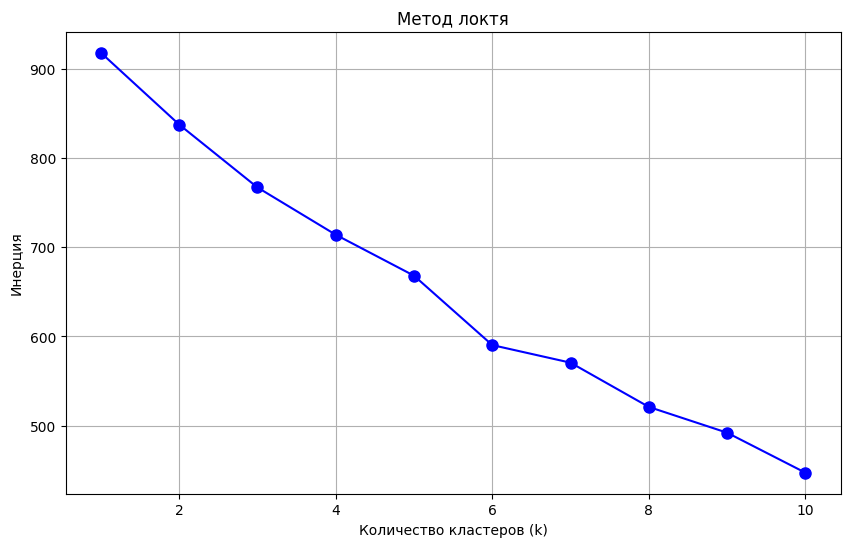

In [3]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# 1. Выбираем числовые колонки
X = df.select_dtypes(include=[np.number])

# 2. Масштабируем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Метод локтя
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. График
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-', markersize=8)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

In [1]:
import pandas as pd
import os

path = "../data/dataset_for_regression.csv"

if os.path.exists(path):
    df = pd.read_csv(path)
    print("✅ Данные загружены")
    display(df.head())
else:
    print("❌ Файл не найден")

✅ Данные загружены


,visual,practice,ai_use,ai_help,ai_understand,minimalism,practice_best,notes,study_type,study_time,...,ai_purpose_fun,ai_purpose_study,perception_video_images,perception_memorization,perception_practice,perception_text,learning_style_visual,learning_style_memorization,learning_style_minimalism,learning_style_practical
0,2,2,1,1,2,0,0,3,0,0,...,0,1,0,0,1,0,0,0,0,1
1,3,2,1,2,4,1,0,2,0,1,...,0,1,0,0,1,0,0,0,0,1
2,2,1,2,2,3,0,1,1,1,2,...,1,1,0,1,0,0,0,1,0,0
3,2,1,2,2,4,1,1,1,1,2,...,1,1,0,0,1,0,0,0,0,1
4,4,1,2,2,2,1,0,2,1,3,...,0,1,0,0,1,0,1,0,0,0
